# Oscilloscope Driver Test Notebook

This notebook provides a **comprehensive, sequential test** of every function in the Oscilloscope driver class hierarchy:

| Layer | Class | Key Methods |
|---|---|---|
| 1 | `Instrument` | `idn()` |
| 2 | `Scpi` | `reset()`, `clear()`, `error()`, `wait()`, `self_test()`, `operation_complete()`, `initialize()` |
| 3 | `Oscilloscope` | Channel, Horizontal, Trigger, Acquisition, and Data methods |

---

**Instructions for the Technician:**
1. Ensure an oscilloscope is connected and powered on.
2. Run each cell **sequentially** from top to bottom.
3. After each cell, verify the **Expected Result** described in the markdown cell that follows.
4. If a cell produces an error or the scope does not behave as expected, **STOP** and note the failing section.
5. A signal source (e.g., probe compensation output, function generator) connected to **Channel 1** is recommended for trigger and acquisition tests.

---
## 0. Setup & Connection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from piec.drivers.autodetect import autodetect

In [2]:
# --- Option A: Auto-detect the oscilloscope ---
scope = autodetect("scope", verbose=True)

# --- Option B: Manually specify the address and driver ---
# from piec.drivers.oscilloscope.k_dsox3024a import KeysightDSOX3024a
# scope = KeysightDSOX3024a("GPIB0::7::INSTR")  # Replace with actual address

Autodetect: Scanning for instrument of type Oscilloscope...
  -> Checking GPIB0::6::INSTR...
Autodetect: Probing GPIB0::6::INSTR...
[OPTIONAL SKIP] close is not available on Scpi — skipping.
  -> IDN: *IDN LECROY,SDA6020,SDA00708,6.1.0
Autodetect: Loaded piec.drivers.oscilloscope.lecroy_sda6020.LeCroySDA6020 for instrument at GPIB0::6::INSTR
  -> MATCH: GPIB0::6::INSTR is a Oscilloscope!


**Expected Result:** The cell should print connection information and return without error. If using autodetect, the detected instrument model should be printed.

---
## 1. Instrument-Level Tests (`Instrument` base class)
These tests verify the most fundamental capability: identification.

### 1.1 Identification (`idn`)

In [3]:
# Query the instrument's identification string
idn_response = scope.idn()
print("IDN Response:")
print(idn_response)

IDN Response:
*IDN LECROY,SDA6020,SDA00708,6.1.0



In [5]:
scope.instrument.write("CLSW")


6

Example: `KEYSIGHT TECHNOLOGIES,DSOX3024A,MY12345678,07.50.2021102830`  

**PASS** if the printed string matches your physical instrument's make/model.

---
## 2. SCPI-Level Tests (`Scpi` base class)
These tests verify the IEEE 488.2 mandated commands that all SCPI instruments must support.

### 2.1 Reset (`reset`)

In [4]:
# Reset the instrument to its factory default state
scope.reset()
print("Reset command sent.")

Reset command sent.


**PASS** if the scope display resets. No Python output is expected (returns `None`).

### 2.2 Clear Status (`clear`)

In [7]:
# Clear the status registers and error queue
scope.clear()
print("Clear command sent.")

Clear command sent.


**PASS** if no error is raised.

### 2.3 Error Query (`error`)

In [8]:
# Query the error status register
error_response = scope.error()
print("Error Status Register:")
print(error_response)

Error Status Register:
*ESR 0



**PASS** if the returned value is `0`.

### 2.4 Self Test (`self_test`)

In [5]:
# Run the instrument's internal self-test
# NOTE: This may take several seconds to complete
self_test_result = scope.self_test()
print("Self-test result:")
print(self_test_result)

Self-test result:
*TST 0



**Note:** This command may take 10-30 seconds to execute. The scope display may go blank during the test.

**PASS** if `0` is returned.

### 2.5 Wait (`wait`)

In [6]:
# Wait for all pending operations to complete
scope.wait()
print("Wait command sent.")

Wait command sent.


**PASS** if no error is raised.

### 2.6 Operation Complete (`operation_complete`)

In [9]:
# Check if the last operation is complete
opc_result = scope.operation_complete()
print("Operation Complete:")
print(opc_result)

Operation Complete:
*OPC 1



**PASS** if `1` is returned.

### 2.7 Initialize (`initialize`)
This is a convenience method that calls `reset()` followed by `clear()`.

In [15]:
# Initialize the instrument (reset + clear)
scope.initialize()
print("Initialize command sent (reset + clear).")

Initialize command sent (reset + clear).


**PASS** if the scope resets and no error is raised.

---
## 3. Channel Configuration Tests (`Oscilloscope` class)
These tests verify per-channel display and input settings.

### 3.1 Autoscale (`autoscale`)

In [6]:
# Autoscale the oscilloscope to fit all active signals
scope.autoscale()

**PASS** if the scope display adjusts to show a clean signal.

### 3.2 Toggle Channel (`toggle_channel`)

In [14]:
# Turn Channel 2 OFF
scope.toggle_channel(channel=2, on=False)
print("Channel 2 turned OFF.")

Channel 2 turned OFF.


**PASS** if Channel 2 is no longer visible on the display.

In [15]:
# Turn Channel 2 back ON
scope.toggle_channel(channel=2, on=True)
print("Channel 2 turned ON.")

Channel 2 turned ON.


**PASS** if Channel 2 is visible again.

### 3.3 Set Vertical Scale (`set_vertical_scale`) — Volts/Division

In [16]:
# Set Channel 1 vertical scale to 500 mV/div
scope.set_vertical_scale(channel=1, vdiv=0.5)
print("Channel 1 set to 500 mV/div.")

Channel 1 set to 500 mV/div.


**PASS** if the Channel 1 V/div matches 500 mV.

### 3.4 Set Vertical Scale (`set_vertical_scale`) — Absolute Range

In [17]:
# Set Channel 1 vertical range to 10 V total (= 1.25 V/div across 8 divisions)
scope.set_vertical_scale(channel=1, y_range=10.0)
print("Channel 1 set to 10 V range (1.25 V/div).")

Channel 1 set to 10 V range (1.25 V/div).


**PASS** if the V/div is approximately 1.25 V.

### 3.5 Set Vertical Position (`set_vertical_position`)

In [18]:
# Shift Channel 1 waveform down by offsetting the vertical position to -1.0 V
scope.set_vertical_position(channel=1, y_position=-1.0)
print("Channel 1 vertical position set to -1.0 V.")

Channel 1 vertical position set to -1.0 V.


**PASS** if the waveform moves up or down from its previous position.

In [19]:
# Reset the vertical position back to 0 V
scope.set_vertical_position(channel=1, y_position=0.0)
print("Channel 1 vertical position reset to 0 V.")

Channel 1 vertical position reset to 0 V.


**PASS** if the ground reference is centered.

### 3.6 Set Input Coupling (`set_input_coupling`)

In [20]:
# Set Channel 1 coupling to AC
scope.set_input_coupling(channel=1, input_coupling='AC')
print("Channel 1 coupling set to AC.")

Channel 1 coupling set to AC.


**PASS** if the coupling indicator shows AC.

In [21]:
# Set Channel 1 coupling back to DC
scope.set_input_coupling(channel=1, input_coupling='DC')
print("Channel 1 coupling set to DC.")

Channel 1 coupling set to DC.


**PASS** if the coupling indicator shows DC.

### 3.7 Set Probe Attenuation (`set_probe_attenuation`)

In [22]:
# Set Channel 1 probe attenuation to 10x
scope.set_probe_attenuation(channel=1, probe_attenuation=10)
print("Channel 1 probe attenuation set to 10x.")

Channel 1 probe attenuation set to 10x.


**PASS** if the probe indicator shows 10x (or voltage scales update accordingly).

In [23]:
# Set Channel 1 probe attenuation back to 1x
scope.set_probe_attenuation(channel=1, probe_attenuation=1)
print("Channel 1 probe attenuation set to 1x.")

Channel 1 probe attenuation set to 1x.


**PASS** if voltage readings return to direct measurement values.

### 3.8 Set Channel Impedance (`set_channel_impedance`)

In [24]:
# Set Channel 1 input impedance to 50 Ohm
scope.set_channel_impedance(channel=1, channel_impedance='50')
print("Channel 1 impedance set to 50 Ohm.")

Channel 1 impedance set to 50 Ohm.


**Note:** Not all scopes support 50 Ω termination on all channels. If your scope does not support this, expect an error or no visible change.

**PASS** if the impedance indicator shows 50 Ω, or the driver raises a clear informational message if unsupported.

---
## 4. Horizontal (Timebase) Configuration Tests

### 4.1 Set Horizontal Scale — Time/Division (`set_horizontal_scale`)

In [25]:
# Set timebase to 1 ms/div
scope.set_horizontal_scale(tdiv=0.001)
print("Horizontal scale set to 1 ms/div.")

Horizontal scale set to 1 ms/div.


**PASS** if the timebase matches 1 ms/div.

### 4.2 Set Horizontal Position / Delay (`set_horizontal_position`)

In [26]:
# Introduce a 500 µs delay (trigger point shifts left)
scope.set_horizontal_position(x_position=0.0005)
print("Horizontal position set to 500 µs delay.")

Horizontal position set to 500 µs delay.


**PASS** if the trigger marker is offset from center.

### 4.3 Configure Horizontal — Combined (`configure_horizontal`)

In [27]:
# Set timebase to 100 µs/div and reset delay to 0
scope.configure_horizontal(tdiv=0.0001, x_position=0)
print("Horizontal configured: 100 µs/div, 0 s delay.")

Horizontal configured: 100 µs/div, 0 s delay.


**PASS** if both values match on the scope display.

---
## 5. Trigger Configuration Tests

### 5.1 Set Trigger Source (`set_trigger_source`)

In [28]:
# Set trigger source to Channel 1
scope.set_trigger_source(trigger_source=1)
print("Trigger source set to Channel 1.")

Trigger source set to Channel 1.


**PASS** if the trigger source matches.

### 5.2 Set Trigger Level (`set_trigger_level`)

In [29]:
# Set trigger level to 1.0 V
scope.set_trigger_level(trigger_level=1.0)
print("Trigger level set to 1.0 V.")

Trigger level set to 1.0 V.


**PASS** if the trigger level indicator matches.

### 5.3 Set Trigger Slope (`set_trigger_slope`)

In [30]:
# Set trigger slope to Positive (Rising edge)
scope.set_trigger_slope(trigger_slope='POS')
print("Trigger slope set to Positive (rising edge).")

Trigger slope set to Positive (rising edge).


**PASS** if the trigger slope indicator matches.

In [31]:
# Test with Negative (Falling edge)
scope.set_trigger_slope(trigger_slope='NEG')
print("Trigger slope set to Negative (falling edge).")

Trigger slope set to Negative (falling edge).


**PASS** if the trigger slope indicator matches.

### 5.4 Set Trigger Mode (`set_trigger_mode`)

In [32]:
# Set trigger mode to Edge triggering
scope.set_trigger_mode(trigger_mode='EDGE')
print("Trigger mode set to EDGE.")

Trigger mode set to EDGE.


**PASS** if the trigger mode indicator shows Edge.

### 5.5 Set Trigger Sweep (`set_trigger_sweep`)

In [33]:
# Set trigger sweep to Normal mode
scope.set_trigger_sweep(trigger_sweep='NORM')
print("Trigger sweep set to NORMAL.")

Trigger sweep set to NORMAL.


**PASS** if the sweep mode shows Normal.

In [34]:
# Set trigger sweep to Auto mode
scope.set_trigger_sweep(trigger_sweep='AUTO')
print("Trigger sweep set to AUTO.")

Trigger sweep set to AUTO.


**PASS** if the sweep mode shows Auto.

### 5.6 Configure Trigger — Combined (`configure_trigger`)

In [35]:
# Configure all trigger settings in one call
scope.configure_trigger(
    trigger_source=1,
    trigger_level=1.5,
    trigger_slope='POS',
    trigger_mode='EDGE'
)
print("Trigger configured: CH1, 1.5 V, Positive edge, Edge mode.")

Trigger configured: CH1, 1.5 V, Positive edge, Edge mode.


**PASS** if all four trigger parameters match on the scope display.

### 5.7 Manual (Force) Trigger (`manual_trigger`)

In [36]:
# First set sweep to Normal so the scope waits for a trigger event
scope.set_trigger_sweep(trigger_sweep='NORM')

# Now force a trigger manually
scope.manual_trigger()
print("Manual trigger sent.")

Manual trigger sent.


**PASS** if the display updates after the manual trigger command.

---
## 6. Acquisition Control Tests

### 6.1 Toggle Acquisition — Stop (`toggle_acquisition`)

In [39]:
# Stop the acquisition
scope.toggle_acquisition(run=False)
print("Acquisition STOPPED.")

Acquisition STOPPED.


**PASS** if the scope is stopped and the display no longer updates.

### 6.2 Toggle Acquisition — Run (`toggle_acquisition`)

In [40]:
# Resume acquisition
scope.toggle_acquisition(run=True)
print("Acquisition RUNNING.")

Acquisition RUNNING.


**PASS** if the scope is running and the display is updating.

### 6.3 Set Acquisition Channel (`set_acquisition_channel`)

In [41]:
# Set the acquisition source to Channel 1
scope.set_acquisition_channel(channel=1)
print("Acquisition source set to Channel 1.")

Acquisition source set to Channel 1.


**PASS** if no error is raised.

### 6.4 Set Acquisition Mode (`set_acquisition_mode`)

In [42]:
# Set acquisition mode to Normal
scope.set_acquisition_mode(acquisition_mode='NORM')
print("Acquisition mode set to NORMAL.")

Acquisition mode set to NORMAL.


**PASS** if no error is raised and the mode corresponds to Normal.

### 6.5 Set Acquisition Points (`set_acquisition_points`)

In [43]:
# Set the number of acquisition points to 10,000
scope.set_acquisition_points(acquisition_points=10000)
print("Acquisition points set to 10,000.")

Acquisition points set to 10,000.


**PASS** if no error is raised.

### 6.6 Configure Acquisition — Combined (`configure_acquisition`)

In [44]:
# Configure acquisition with all parameters at once
scope.configure_acquisition(
    channel=1,
    acquisition_mode='NORM',
    acquisition_points=10000
)
print("Acquisition configured: CH1, Normal mode, 10,000 points.")

Acquisition configured: CH1, Normal mode, 10,000 points.


**PASS** if no error is raised. These settings will take effect when data is retrieved.

### 6.7 Arm for Single Shot (`arm`)

In [45]:
# Set trigger sweep to AUTO so the scope will trigger even without a signal
scope.set_trigger_sweep(trigger_sweep='AUTO')

# Arm the scope for a single-shot acquisition
scope.arm()
print("Scope armed for single-shot acquisition.")

Scope armed for single-shot acquisition.


**Technician Note:** If trigger sweep is set to NORM and no valid trigger signal is present, the scope will wait indefinitely. We set AUTO above so it will auto-trigger.  

**PASS** if the scope arms and eventually triggers (in AUTO mode).

### 6.8 Set Acquisition (`set_acquisition`)

In [46]:
# Set up the acquisition system to prepare for data transfer
scope.set_acquisition()
print("Acquisition system prepared for data transfer.")

Acquisition system prepared for data transfer.


**PASS** if no error is raised.

---
## 7. Data Retrieval Tests

### 7.1 Quick Read (`quick_read`)

In [47]:
# Make sure the scope is running or has a captured waveform
scope.toggle_acquisition(run=True)
import time
time.sleep(1)  # Allow a waveform to be acquired

# Perform a quick read of whatever is currently on screen
quick_data = scope.quick_read()
print(f"Quick read returned {type(quick_data).__name__} with {len(quick_data)} points.")
print("First 10 values:")
print(quick_data[:10])

Quick read returned ndarray with 100002 points.
First 10 values:
[-256 -256  256    0  256 -256 -256 -256  256 -256]


**PASS** if a numpy array is returned with numeric data and a sensible length.

### 7.2 Get Data (`get_data`)

In [48]:
# Get the fully configured data as a Pandas DataFrame
data_df = scope.get_data()
print(f"get_data returned DataFrame with shape: {data_df.shape}")
print(f"Columns: {list(data_df.columns)}")
print("\nFirst 5 rows:")
data_df.head()

get_data returned DataFrame with shape: (100002, 2)
Columns: ['Time', 'Voltage']

First 5 rows:


,Time,Voltage
0,-0.0005,-0.044195
1,-0.0005,-0.044195
2,-0.0005,0.044195
3,-0.0005,0.000000
4,-0.0005,0.044195


- Time values should be in **seconds**, evenly spaced  
- Voltage values should be in **volts**, within the expected range  

**PASS** if a DataFrame is returned with reasonable time and voltage data.

### 7.3 Plot the Acquired Data

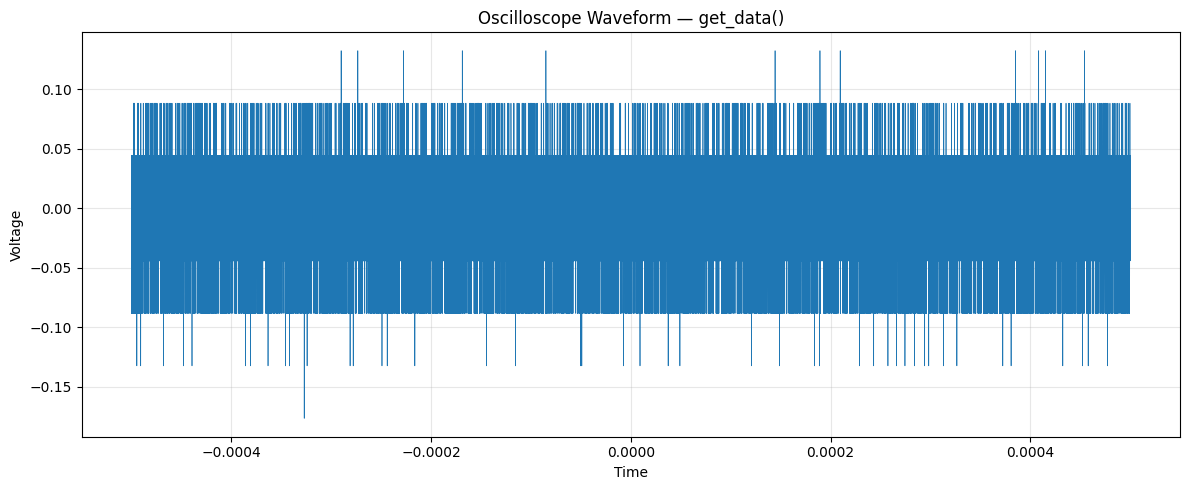

In [49]:
# Plot the acquired waveform for visual verification
plt.figure(figsize=(12, 5))

# Attempt to detect column names (different drivers may use different names)
cols = data_df.columns.tolist()
x_col = cols[0]  # First column is typically Time
y_col = cols[1]  # Second column is typically Voltage

plt.plot(data_df[x_col], data_df[y_col], linewidth=0.5)
plt.title("Oscilloscope Waveform — get_data()")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**PASS** if the plot shows a recognizable waveform consistent with the connected signal.

---
## 8. Cleanup & Final Reset

In [50]:
# Reset the instrument to a known state
scope.reset()
print("Scope reset to factory defaults.")

Scope reset to factory defaults.


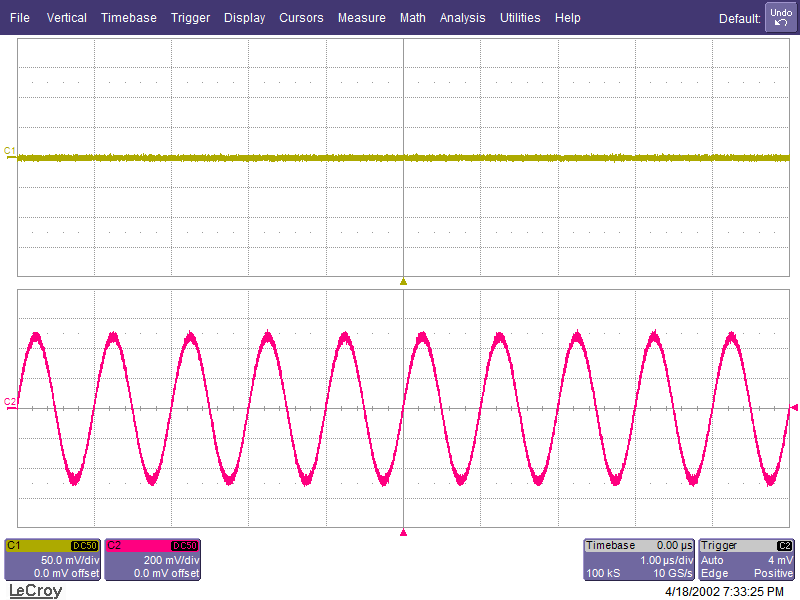

In [4]:
from IPython.display import display, Image
png_data = scope.screenshot()
display(Image(data=png_data))

**PASS** if the scope resets successfully.